In [1]:
# 얼마나 많은 고객이 있는가? 96,096명
# 고객은 주로 어디에 살고 있는가? sao paulo > rio de janeiro > belo horizonte
# 도시명 (문자열) => 범주형 데이터 (절대, 상대) => 막대바, 원형
# 고객은 주로 어떤 결제방법을 선택하고 있는가? credit_card > boleto > voucher

# 브라질 : 빈민층 -> 가난!!
# 초등학교 x -> 길거리 폐지, 공을 만들어서 축구 (축구 -> 사람(축구))
# 신용카드 -> x, boleto

In [2]:
import pandas as pd

PATH = "00_data"

In [3]:
products = pd.read_csv(f"{PATH}/olist_products_dataset.csv", encoding="utf-8-sig")
customers= pd.read_csv(f"{PATH}/olist_customers_dataset.csv", encoding="utf-8-sig")
geolocation = pd.read_csv(f"{PATH}/olist_geolocation_dataset.csv", encoding="utf-8-sig")
order_items = pd.read_csv(f"{PATH}/olist_order_items_dataset.csv", encoding="utf-8-sig")
payments = pd.read_csv(f"{PATH}/olist_order_payments_dataset.csv", encoding="utf-8-sig")
reviews = pd.read_csv(f"{PATH}/olist_order_reviews_dataset.csv", encoding="utf-8-sig")
orders = pd.read_csv(f"{PATH}/olist_orders_dataset.csv", encoding="utf-8-sig")
sellers = pd.read_csv(f"{PATH}/olist_sellers_dataset.csv", encoding="utf-8-sig")
category_name = pd.read_csv(f"{PATH}/product_category_name_translation.csv", encoding="utf-8-sig")

In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
# 데이터 영역, unique visitor=> "순" 방문자 => 1명이 3번 방문 -> 1명이라는 숫자를 집계

In [7]:
customers["customer_unique_id"].value_counts() # 특정요소의 값이 몇 번 사용되었는가

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
081f07439678af2da7755a0aa572154d     1
9c57789a6a587f4efcfb01e36c106014     1
9e4c21635f640562de1a6976374fba03     1
06c0ea6ee892364d1608ee47aa9f56a0     1
84732c5050c01db9b23e19ba39899398     1
Name: count, Length: 96096, dtype: int64

In [10]:
customers["customer_unique_id"].value_counts().max() # 최대값 -> 가장최대로 많이 중복된 값

17

In [8]:
customers["customer_id"].value_counts()

customer_id
06b8999e2fba1a1fbc88172c00ba8bc7    1
c023f30c1147aeb0358474f3b1dbc707    1
b5cbf43f42281920a175fc99650c91d6    1
19f4e983f8f05b7de16670f8a0cf0ac7    1
229ac14c6ee6d6a606264ebcc861beb7    1
                                   ..
31665bd5bc542687ab54c9fd9ed9917b    1
37fb9cce079a4887c96b59bae2011d05    1
1d815f3ad9b2017b6da2c4f1cbb1180b    1
6b05c8f3a25a71005d5eb9b51766c333    1
274fa6071e5e17fe303b9748641082c8    1
Name: count, Length: 99441, dtype: int64

In [11]:
customers["customer_id"].value_counts().max() # 최대값 -> 가장최대로 많이 중복된 값

1

In [13]:
customers["customer_id"].nunique() # 유니크한 값의 갯수를 확인

99441

In [14]:
customers["customer_unique_id"].nunique() # 전체행수보다 작게 출력 => 중복해서 사용된 값이 존재했다

96096

In [15]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [33]:
# customers_location = customers.groupby("customer_city")["customer_unique_id"].nunique().sort_values(ascending=False)
# customers_location = customers.groupby("customer_city")["customer_unique_id"]\
#                     .nunique()\
#                     .sort_values(ascending=False)
customers_location = (
    customers.groupby("customer_city")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)
# nunique() -> 인덱스값인 "customer_city"를 기준으로 "customer_unique_id"의 갯수를 파악하기 위한 고유식별값을 연산해주는 메서드
# 메서드 체이닝 = Method Chaining
# 클래스 => 객체지향 프로그래밍 언어 핵심
# 메서드, 함수 => 뿌리 동일하다 = 기능 동일하다 (매개변수 -> 연산 -> 출력)
# 파이썬 언어 문법 => 문장의 종결을 구분짓는 표기방법이 존재 x -> 임의로 개행 x
# 문법의 문장 가독성 => 개행 -> \

customers_location_top20 = customers_location.head(20)

In [32]:
customers_location.head(20)

customer_city
sao paulo                14984
rio de janeiro            6620
belo horizonte            2672
brasilia                  2069
curitiba                  1465
campinas                  1398
porto alegre              1326
salvador                  1209
guarulhos                 1153
sao bernardo do campo      908
niteroi                    811
santo andre                769
osasco                     717
santos                     692
goiania                    671
sao jose dos campos        666
fortaleza                  643
sorocaba                   610
recife                     590
jundiai                    547
Name: customer_unique_id, dtype: int64

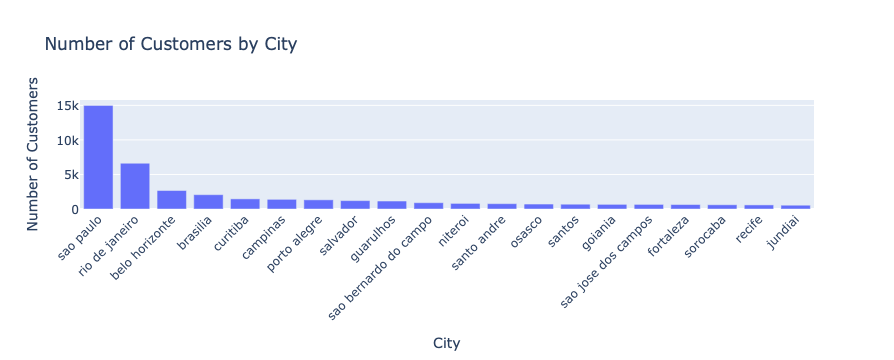

In [34]:
import plotly.express as px

fig = px.bar(
    x = customers_location_top20.index,
    y = customers_location_top20.values,
    title = "Number of Customers by City",
    labels= {"x": "City", "y": "Number of Customers"}
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [37]:
top20_customers_location = customers_location_top20.index

In [40]:
top20_customers_location

Index(['sao paulo', 'rio de janeiro', 'belo horizonte', 'brasilia', 'curitiba',
       'campinas', 'porto alegre', 'salvador', 'guarulhos',
       'sao bernardo do campo', 'niteroi', 'santo andre', 'osasco', 'santos',
       'goiania', 'sao jose dos campos', 'fortaleza', 'sorocaba', 'recife',
       'jundiai'],
      dtype='object', name='customer_city')

In [39]:
type(top20_customers_location)

pandas.core.indexes.base.Index

In [46]:
# 형변환 => 파이썬 문법 초창기 형변환
# int(), float(), list()

for index, location in enumerate(list(top20_customers_location)) :
    print(f"TOP {index + 1}. {location}")

TOP 1. sao paulo
TOP 2. rio de janeiro
TOP 3. belo horizonte
TOP 4. brasilia
TOP 5. curitiba
TOP 6. campinas
TOP 7. porto alegre
TOP 8. salvador
TOP 9. guarulhos
TOP 10. sao bernardo do campo
TOP 11. niteroi
TOP 12. santo andre
TOP 13. osasco
TOP 14. santos
TOP 15. goiania
TOP 16. sao jose dos campos
TOP 17. fortaleza
TOP 18. sorocaba
TOP 19. recife
TOP 20. jundiai


In [47]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [48]:
payments.shape

(103886, 5)

In [49]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [51]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [52]:
# 결제수단 방법?

payments["payment_type"].unique() # 특정 데이터프레임 > 컬럼 > 값 > 중복을 제거한 상태의 고유값을 확인

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [60]:
payments = payments[payments["payment_type"] != "not_defined"]

In [61]:
payments["payment_type"].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card'], dtype=object)

In [62]:
payment_type_count = (payments.groupby("payment_type")["order_id"].
                      nunique().
                      sort_values(ascending=False)
)

payment_type_count

payment_type
credit_card    76505
boleto         19784
voucher         3866
debit_card      1528
Name: order_id, dtype: int64

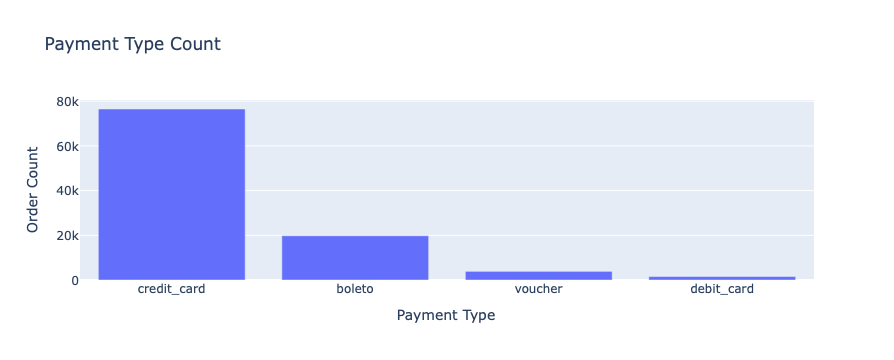

In [64]:
import plotly.express as px

fig = px.bar(
    x = payment_type_count.index,
    y = payment_type_count.values,
    title = "Payment Type Count",
    labels = {"x": "Payment Type", "y": "Order Count"}
)

fig.show()

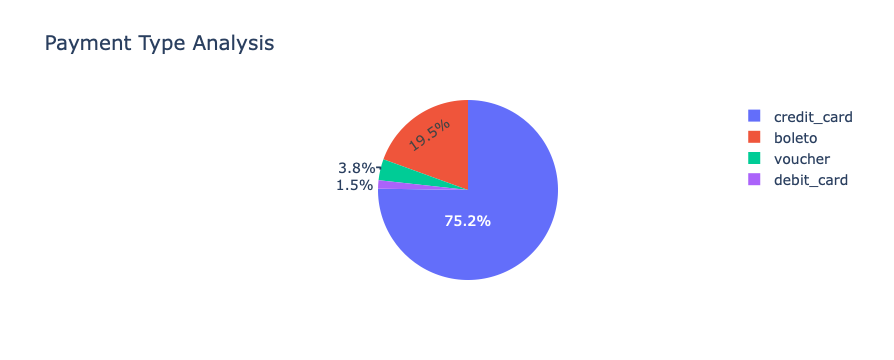

In [80]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Pie(
        labels=payment_type_count.index,
        values=payment_type_count.values,
        textinfo="percent", # label+percent, label, value, percent
        insidetextorientation="tangential" # horizontal, radial, tangential
    )
)

fig.update_layout(
    {
        "title": "Payment Type Analysis",
        "font": {
            "size": 14
        }
    }
)

fig.show()